In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.2 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

print("YOLO Installed Successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO Installed Successfully


In [4]:
import os

dataset_path = "/content/drive/MyDrive/helmet_dataset/helmets.yolov11"

print("Files inside dataset folder:")
print(os.listdir(dataset_path))

Files inside dataset folder:
['README.roboflow.txt', 'data.yaml', 'train', 'valid', 'test']


In [5]:
yaml_path = "/content/drive/MyDrive/helmet_dataset/helmets.yolov11/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['helmet']

roboflow:
  workspace: shreyass-workspace-b44jf
  project: helmets-7p6sp-3d3pc
  version: dataset
  license: CC BY 4.0
  url: https://app.roboflow.com/shreyass-workspace-b44jf/helmets-7p6sp-3d3pc/dataset


In [6]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [7]:
yaml_path = "/content/drive/MyDrive/helmet_dataset/helmets.yolov11/data.yaml"

print("Dataset YAML Path:")
print(yaml_path)

Dataset YAML Path:
/content/drive/MyDrive/helmet_dataset/helmets.yolov11/data.yaml


In [8]:
results = model.train(
    data="/content/drive/MyDrive/helmet_dataset/helmets.yolov11/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="helmet_detection",
    name="yolo11s_experiment_1"
)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/helmet_dataset/helmets.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_experiment_1, nbs=64, nms=False, opset=None, optimize=False,

In [9]:
import os

results_path = "/content/runs/detect/helmet_detection/yolo11s_experiment_1"

print(os.listdir(results_path))

['val_batch0_labels.jpg', 'confusion_matrix.png', 'labels.jpg', 'val_batch1_labels.jpg', 'BoxR_curve.png', 'train_batch962.jpg', 'args.yaml', 'BoxF1_curve.png', 'BoxP_curve.png', 'train_batch960.jpg', 'train_batch1.jpg', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'val_batch1_pred.jpg', 'train_batch961.jpg', 'results.png', 'weights', 'train_batch0.jpg', 'results.csv', 'train_batch2.jpg', 'val_batch0_pred.jpg']


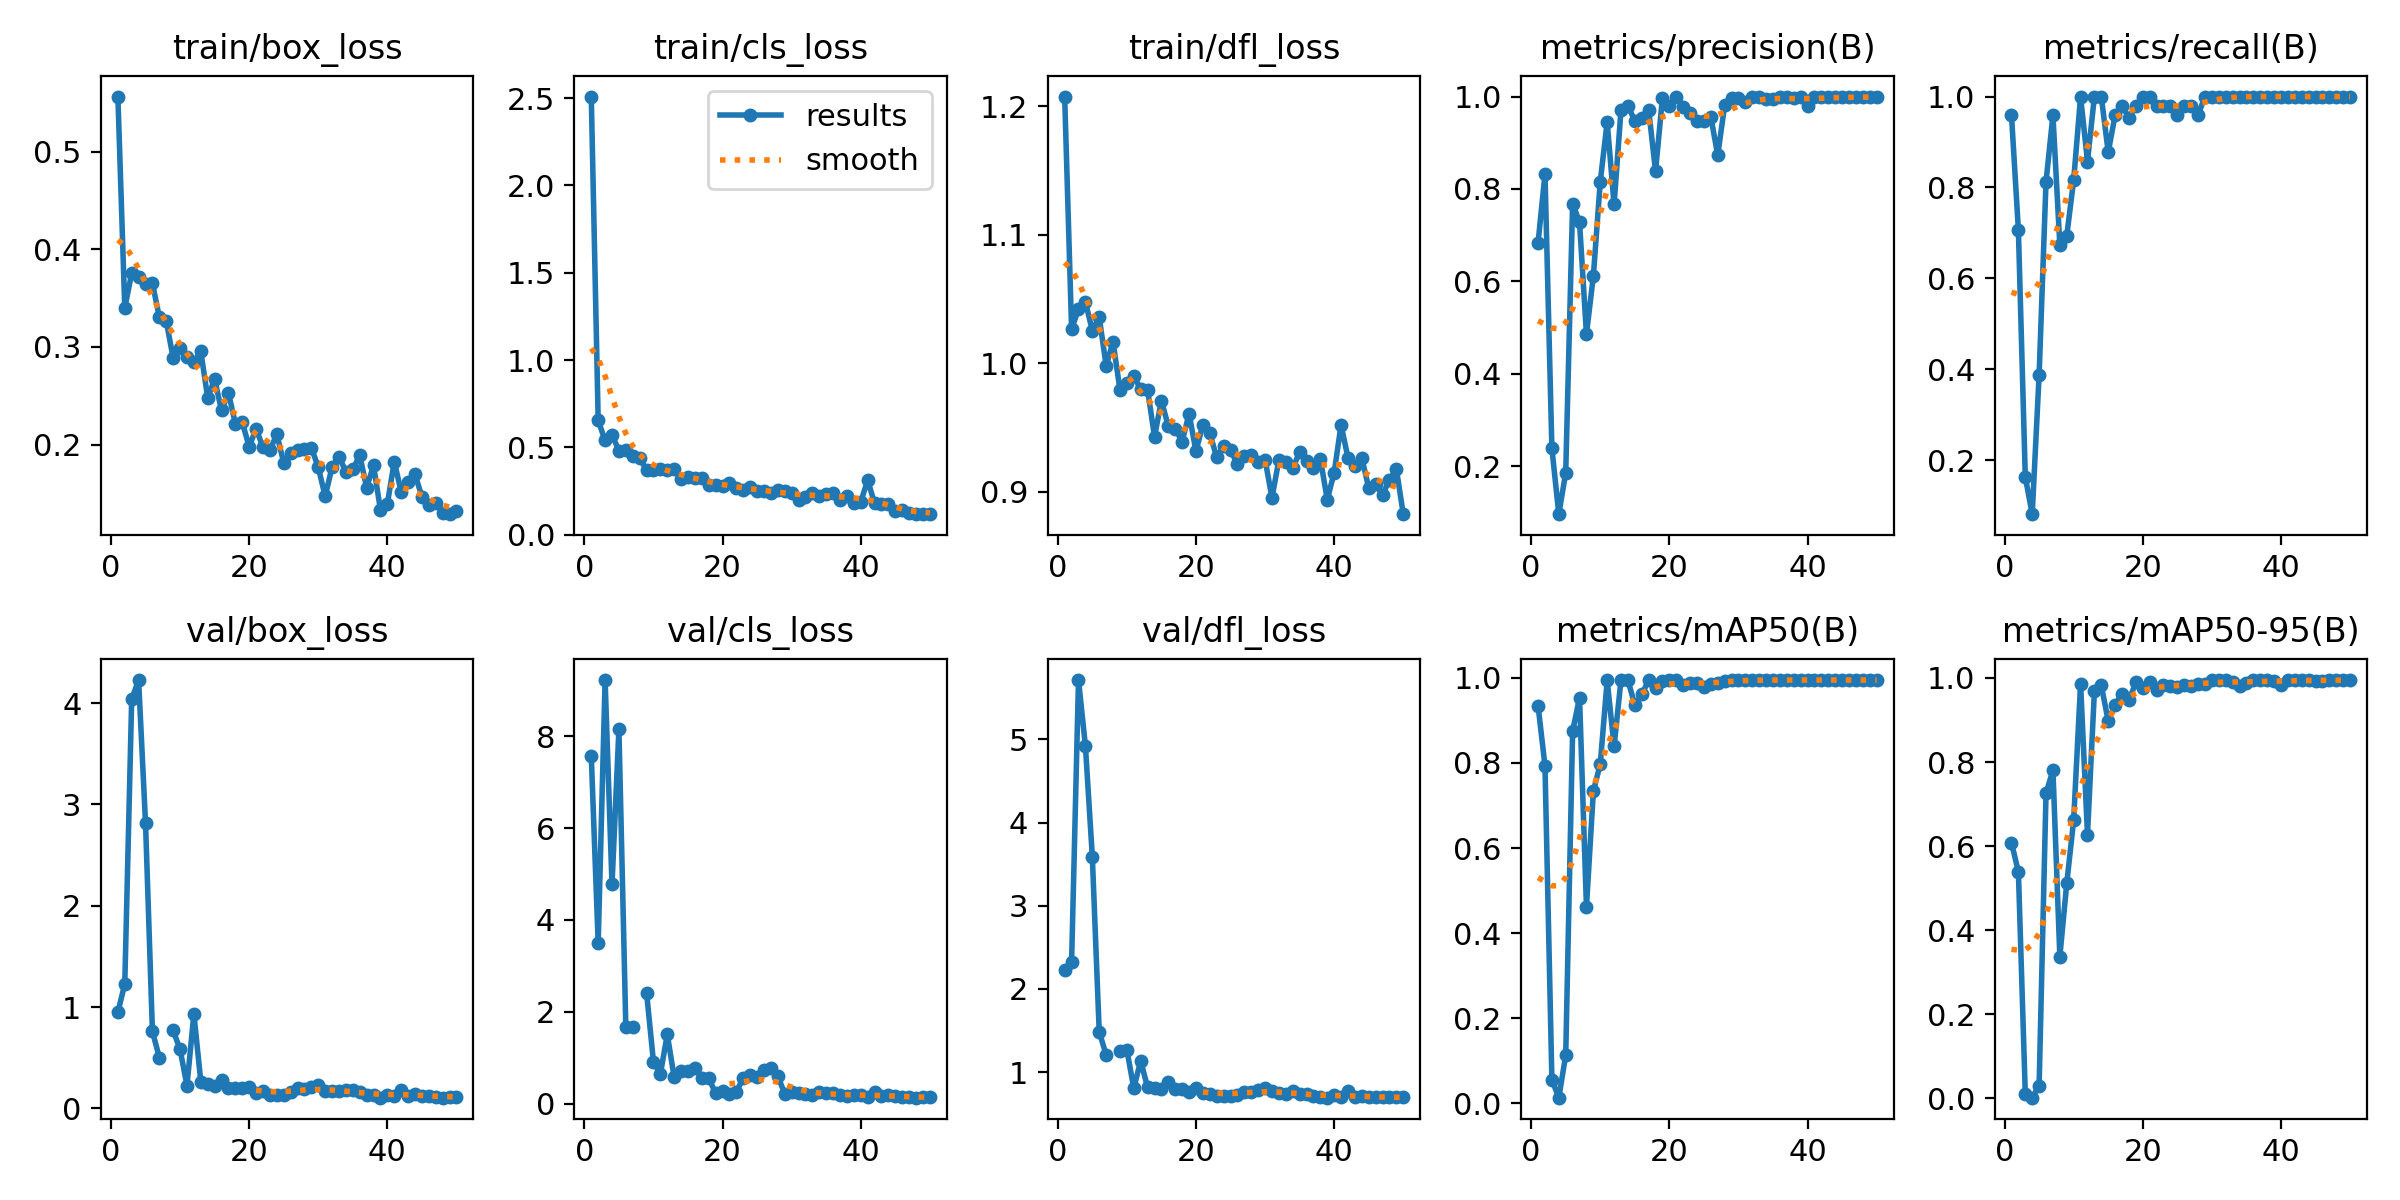

In [10]:
from IPython.display import Image

Image("/content/runs/detect/helmet_detection/yolo11s_experiment_1/results.png")

In [11]:
import os

weights_path = "/content/runs/detect/helmet_detection/yolo11s_experiment_1/weights"

print(os.listdir(weights_path))

['last.pt', 'best.pt']


In [12]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/helmet_detection/yolo11s_experiment_1/weights/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/helmet_test_images",
    save=True,
    conf=0.25
)


image 1/10 /content/drive/MyDrive/helmet_test_images/h1.jpg: 448x640 1 helmet, 54.3ms
image 2/10 /content/drive/MyDrive/helmet_test_images/h10.jpg: 448x640 1 helmet, 12.1ms
image 3/10 /content/drive/MyDrive/helmet_test_images/h2.jpg: 384x640 (no detections), 60.4ms
image 4/10 /content/drive/MyDrive/helmet_test_images/h3.jpg: 480x640 2 helmets, 58.2ms
image 5/10 /content/drive/MyDrive/helmet_test_images/h4.jpg: 352x640 2 helmets, 57.7ms
image 6/10 /content/drive/MyDrive/helmet_test_images/h5.jpg: 448x640 2 helmets, 12.7ms
image 7/10 /content/drive/MyDrive/helmet_test_images/h6.jpg: 640x640 1 helmet, 16.3ms
image 8/10 /content/drive/MyDrive/helmet_test_images/h7.jpg: 640x640 1 helmet, 15.6ms
image 9/10 /content/drive/MyDrive/helmet_test_images/h8.jpg: 448x640 3 helmets, 12.7ms
image 10/10 /content/drive/MyDrive/helmet_test_images/h9.jpg: 448x640 3 helmets, 14.2ms
Speed: 2.1ms preprocess, 31.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/ru

In [13]:
import os

print(os.listdir("/content/runs/detect/predict"))

['h5.jpg', 'h4.jpg', 'h10.jpg', 'h3.jpg', 'h6.jpg', 'h9.jpg', 'h2.jpg', 'h1.jpg', 'h7.jpg', 'h8.jpg']


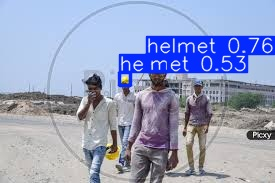

In [14]:
from IPython.display import Image, display

display(Image("/content/runs/detect/predict/h5.jpg"))

In [15]:
import os

results_path = "/content/runs/detect/helmet_detection/yolo11s_experiment_1"

for file in os.listdir(results_path):
    print(file)

val_batch0_labels.jpg
confusion_matrix.png
labels.jpg
val_batch1_labels.jpg
BoxR_curve.png
train_batch962.jpg
args.yaml
BoxF1_curve.png
BoxP_curve.png
train_batch960.jpg
train_batch1.jpg
confusion_matrix_normalized.png
BoxPR_curve.png
val_batch1_pred.jpg
train_batch961.jpg
results.png
weights
train_batch0.jpg
results.csv
train_batch2.jpg
val_batch0_pred.jpg


In [16]:
!cp -r /content/runs/detect/helmet_detection/yolo11s_experiment_1 \
/content/drive/MyDrive/Helmet-Detection-YOLOv11/